# **CLEAN DATASET + BASIC ML**

# **1. DATA LOADER**

In [1]:
# read csv to pandas for tabular data
import pandas as pd
df = pd.read_csv('data/food_recipes.csv')
df.head()

,recipe_title,url,record_health,vote_count,rating,description,cuisine,course,diet,prep_time,cook_time,ingredients,instructions,author,tags,category
0,Roasted Peppers And Mushroom Tortilla Pizza Re...,https://www.archanaskitchen.com/roasted-pepper...,good,434,4.958525,is a quicker version pizza to satisfy your cr...,Mexican,Dinner,Vegetarian,15 M,15 M,Tortillas|Extra Virgin Olive Oil|Garlic|Mozzar...,To begin making the Roasted Peppers And Mushro...,Divya Shivaraman,Party Food Recipes|Tea Party Recipes|Mushroom ...,Pizza Recipes
1,Thakkali Gotsu Recipe | Thakkali Curry | Spicy...,https://www.archanaskitchen.com/tomato-gotsu-r...,good,3423,4.932223,also known as the is a quick and easy to ma...,South Indian Recipes,Lunch,Vegetarian,10 M,20 M,Sesame (Gingelly) Oil|Mustard seeds (Rai/ Kadu...,To begin making Tomato Gotsu Recipe/ Thakkali ...,Archana Doshi,Vegetarian Recipes|Tomato Recipes|South Indian...,Indian Curry Recipes
2,Spicy Grilled Pineapple Salsa Recipe,https://www.archanaskitchen.com/spicy-grilled-...,good,2091,4.945959,Spicy Grilled Pineapple Salsa is a simple reci...,Mexican,Side Dish,Vegetarian,10 M,0 M,Extra Virgin Olive Oil|Pineapple|White onion|R...,To begin making the Spicy Grilled Pineapple Sa...,Archana's Kitchen,Party Starter & Appetizer Recipes|Pineapple Re...,Mexican Recipes
3,Karwar Style Dali Thoy Recipe - Toor dal Curry,https://www.archanaskitchen.com/dali-thoy-reci...,good,990,4.888889,The is a quintessential of Konkani dish whic...,Coastal Karnataka,Side Dish,High Protein Vegetarian,5 M,20 M,Arhar dal (Split Toor Dal)|Turmeric powder (Ha...,To prepare Karwar Style Dali Thoy Recipe (Toor...,Jyothi Rajesh,Side Dish Recipes|South Indian Recipes|Indian ...,Indian Curry Recipes
4,Rajma Kofta In Milk And Poppy Seed Gravy Recipe,https://www.archanaskitchen.com/rajma-kofta-in...,good,345,4.828986,Koftas are traditional Indian recipes mostly w...,North Indian Recipes,Side Dish,High Protein Vegetarian,20 M,30 M,Rajma (Large Kidney Beans)|Cashew nuts|Sultana...,To begin making Rajma Kofta In Milk And Poppy ...,RUBY PATHAK,Side Dish Recipes|Indian Lunch Recipes|Office ...,Kofta Recipes


# **2. CLEAN DATASET**

- Notebook này Hỷ sẽ goes through qua tất cả khái niệm về `Feature Engineering` trong Machine Learning nên các bạn đọc kỹ phần hướng dẫn nhé.
- Homework sẽ nằm khắp nơi trong notebook nên các bạn làm song song Hỷ code nhé.

## **2.1. Drop null/invalid records**

### **TODO 1: Drop non-semantic field (Easy)**
- Drop cột `record_health`.

In [2]:
# YOUR CODE GOES HERE
df.drop('record_health', axis=1, inplace=True)
df.head()

,recipe_title,url,vote_count,rating,description,cuisine,course,diet,prep_time,cook_time,ingredients,instructions,author,tags,category
0,Roasted Peppers And Mushroom Tortilla Pizza Re...,https://www.archanaskitchen.com/roasted-pepper...,434,4.958525,is a quicker version pizza to satisfy your cr...,Mexican,Dinner,Vegetarian,15 M,15 M,Tortillas|Extra Virgin Olive Oil|Garlic|Mozzar...,To begin making the Roasted Peppers And Mushro...,Divya Shivaraman,Party Food Recipes|Tea Party Recipes|Mushroom ...,Pizza Recipes
1,Thakkali Gotsu Recipe | Thakkali Curry | Spicy...,https://www.archanaskitchen.com/tomato-gotsu-r...,3423,4.932223,also known as the is a quick and easy to ma...,South Indian Recipes,Lunch,Vegetarian,10 M,20 M,Sesame (Gingelly) Oil|Mustard seeds (Rai/ Kadu...,To begin making Tomato Gotsu Recipe/ Thakkali ...,Archana Doshi,Vegetarian Recipes|Tomato Recipes|South Indian...,Indian Curry Recipes
2,Spicy Grilled Pineapple Salsa Recipe,https://www.archanaskitchen.com/spicy-grilled-...,2091,4.945959,Spicy Grilled Pineapple Salsa is a simple reci...,Mexican,Side Dish,Vegetarian,10 M,0 M,Extra Virgin Olive Oil|Pineapple|White onion|R...,To begin making the Spicy Grilled Pineapple Sa...,Archana's Kitchen,Party Starter & Appetizer Recipes|Pineapple Re...,Mexican Recipes
3,Karwar Style Dali Thoy Recipe - Toor dal Curry,https://www.archanaskitchen.com/dali-thoy-reci...,990,4.888889,The is a quintessential of Konkani dish whic...,Coastal Karnataka,Side Dish,High Protein Vegetarian,5 M,20 M,Arhar dal (Split Toor Dal)|Turmeric powder (Ha...,To prepare Karwar Style Dali Thoy Recipe (Toor...,Jyothi Rajesh,Side Dish Recipes|South Indian Recipes|Indian ...,Indian Curry Recipes
4,Rajma Kofta In Milk And Poppy Seed Gravy Recipe,https://www.archanaskitchen.com/rajma-kofta-in...,345,4.828986,Koftas are traditional Indian recipes mostly w...,North Indian Recipes,Side Dish,High Protein Vegetarian,20 M,30 M,Rajma (Large Kidney Beans)|Cashew nuts|Sultana...,To begin making Rajma Kofta In Milk And Poppy ...,RUBY PATHAK,Side Dish Recipes|Indian Lunch Recipes|Office ...,Kofta Recipes


### **TODO 2: Drop `null` record (Easy)**
- Nhìn vào report từ `df.info()`, chúng ta thấy được có nhiều dòng bị rỗng ở một số trường quan trọng như `prep_time`, `cook_time` (không lẽ nấu mà không biết thời gian) hay `description` (thông thường là do post không miêu tả, những post không đầy đủ tức là không chất lượng).
- Vẫn còn 1 trường `diet` nữa có rất nhiều `null` value, nhưng chúng ta sẽ giải quyết `categorical data` sau nhé.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8009 entries, 0 to 8008
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe_title  8009 non-null   str    
 1   url           8009 non-null   str    
 2   vote_count    8009 non-null   int64  
 3   rating        8009 non-null   float64
 4   description   7994 non-null   str    
 5   cuisine       7943 non-null   str    
 6   course        7854 non-null   str    
 7   diet          7858 non-null   str    
 8   prep_time     7979 non-null   str    
 9   cook_time     7979 non-null   str    
 10  ingredients   7997 non-null   str    
 11  instructions  8009 non-null   str    
 12  author        8009 non-null   str    
 13  tags          7930 non-null   str    
 14  category      8009 non-null   str    
dtypes: float64(1), int64(1), str(13)
memory usage: 19.1 MB


- Hãy giúp Hỷ drop những record bị `null` của những cột trên nha nha.

In [4]:
# YOUR CODE GOES HERE
df.dropna(subset=['prep_time', 'cook_time', 'description', 'ingredients'], inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 7957 entries, 0 to 8008
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe_title  7957 non-null   str    
 1   url           7957 non-null   str    
 2   vote_count    7957 non-null   int64  
 3   rating        7957 non-null   float64
 4   description   7957 non-null   str    
 5   cuisine       7908 non-null   str    
 6   course        7822 non-null   str    
 7   diet          7826 non-null   str    
 8   prep_time     7957 non-null   str    
 9   cook_time     7957 non-null   str    
 10  ingredients   7957 non-null   str    
 11  instructions  7957 non-null   str    
 12  author        7957 non-null   str    
 13  tags          7879 non-null   str    
 14  category      7957 non-null   str    
dtypes: float64(1), int64(1), str(13)
memory usage: 19.0 MB


### **TODO 3: Drop invalid `url` (Easy)**

- Hãy giúp Hỷ đọc file `.txt` ở bước số 2 nhé.

In [5]:
import os
import requests
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

class URLCleaner:
    def __init__(self, df, url_col='url',
                 log_file_v1='invalid_urls_log.txt',
                 log_file_v2='invalid_urls_log_v2.txt',
                 max_workers_v1=10, timeout_v1=10,
                 max_workers_v2=5, timeout_v2=3):
        """
        Khởi tạo class với các cấu hình cần thiết.
        """
        self.df = df
        self.url_col = url_col
        self.log_v1 = log_file_v1
        self.log_v2 = log_file_v2
        self.workers_v1 = max_workers_v1
        self.timeout_v1 = timeout_v1
        self.workers_v2 = max_workers_v2
        self.timeout_v2 = timeout_v2

        # Dùng chung 1 session cho toàn bộ quá trình
        self.session = requests.Session()

    def _check_valid_url(self, idx_url_tuple, timeout):
        """Hàm check URL dùng chung cho cả 2 bước quét"""
        idx, url = idx_url_tuple
        if not isinstance(url, str):
            return idx, False

        try:
            response = self.session.head(url, timeout=timeout, allow_redirects=True)
            return idx, response.status_code < 400
        except:
            return idx, False

    def step1_initial_scan(self):
        """Bước 1: Quét toàn bộ danh sách URL"""
        urls = self.df[self.url_col].tolist()
        tasks = list(enumerate(urls))

        print(f"\n[Bước 1] Đang quét {len(urls)} URLs ({self.workers_v1} luồng, timeout {self.timeout_v1}s)...")

        with open(self.log_v1, "w", encoding="utf-8") as f:
            with ThreadPoolExecutor(max_workers=self.workers_v1) as executor:
                # Truyền tham số timeout_v1 vào hàm check
                futures = [executor.submit(self._check_valid_url, task, self.timeout_v1) for task in tasks]

                for future in tqdm(as_completed(futures), total=len(urls), desc="Scan V1", unit="url"):
                    idx, is_valid = future.result()
                    if not is_valid:
                        f.write(f"{idx}\n")
                        f.flush()
        print(f"[Bước 1] Xong! Lưu log tại '{self.log_v1}'")

    def step2_retry_scan(self):
        """Bước 2: Quét lại những URL bị lỗi ở Bước 1"""

        # YOUR CODE GOES HERE: ĐỌC FILE XUẤT RA Ở BƯỚC 1
        with open(self.log_v1, "r", encoding="utf-8") as f:
            retry_indices = [int(line.strip()) for line in f if line.strip()]
        # ĐỌC CÁC BIẾN Ở TRƯỚC VÀ SAU ĐỂ MÒ NHÉ!

        df_retry = self.df.loc[retry_indices]
        urls_to_retry = list(zip(df_retry.index, df_retry[self.url_col]))

        print(f"\n[Bước 2] Đang quét lại {len(urls_to_retry)} URL nghi ngờ ({self.workers_v2} luồng, timeout {self.timeout_v2}s)...")

        with open(self.log_v2, "w", encoding="utf-8") as f:
            with ThreadPoolExecutor(max_workers=self.workers_v2) as executor:
                # Truyền tham số timeout_v2 vào hàm check
                futures = [executor.submit(self._check_valid_url, task, self.timeout_v2) for task in urls_to_retry]

                for future in tqdm(as_completed(futures), total=len(urls_to_retry), desc="Scan V2 (Retry)", unit="url"):
                    idx, is_valid = future.result()
                    if not is_valid:
                        f.write(f"{idx}\n")
                        f.flush() # Hàm này rất ít dùng, nhưng phổ biến khi chạy đa luồng với lượng data lớn nhá.
        print(f"[Bước 2] Xong! Lưu log chốt hạ tại '{self.log_v2}'")

    def step3_clean_dataframe(self):
        """Bước 3: Loại bỏ các dòng chứa URL lỗi hoàn toàn ra khỏi DataFrame"""
        print(f"\n[Bước 3] Tiến hành làm sạch DataFrame...")

        with open(self.log_v2, "r", encoding="utf-8") as f:
            invalid_indices = [int(line.strip()) for line in f if line.strip()]

        print(f" -> Tìm thấy {len(invalid_indices)} URL chết hoàn toàn.")

        df_clean = self.df.drop(index=invalid_indices, errors='ignore')
        return df_clean

    def run_pipeline(self):
        """Hàm thực thi toàn bộ luồng từ A-Z"""
        print("=== BẮT ĐẦU CHẠY PIPELINE KIỂM TRA URL ===")
        self.step1_initial_scan()
        self.step2_retry_scan()
        df_clean = self.step3_clean_dataframe()
        print("=== PIPELINE KẾT THÚC ===")
        return df_clean

- Rõ ràng code này rất dài so với code của Luân, nhưng chạy lại nhanh gấp 5 lần và chắc chắn đúng hơn code cũ!
- Giờ thì hãy đọc class trên và implement class `URLCleaner` nhé.

In [6]:
# YOUR CODE GOES HERE
df.reset_index(drop=True, inplace=True)# Reset index after cleaning to ensure consistency
my_cleaner = URLCleaner(df)
df = my_cleaner.run_pipeline()
df.shape

=== BẮT ĐẦU CHẠY PIPELINE KIỂM TRA URL ===

[Bước 1] Đang quét 7957 URLs (10 luồng, timeout 10s)...


Scan V1: 100%|██████████| 7957/7957 [07:54<00:00, 16.79url/s]


[Bước 1] Xong! Lưu log tại 'invalid_urls_log.txt'

[Bước 2] Đang quét lại 364 URL nghi ngờ (5 luồng, timeout 3s)...


Scan V2 (Retry): 100%|██████████| 364/364 [00:22<00:00, 16.17url/s]

[Bước 2] Xong! Lưu log chốt hạ tại 'invalid_urls_log_v2.txt'

[Bước 3] Tiến hành làm sạch DataFrame...
 -> Tìm thấy 101 URL chết hoàn toàn.
=== PIPELINE KẾT THÚC ===


(7856, 15)

## **2.2. Thresholding**
- Đối với bài toán làm `forum` và `reccommendation system`, chúng ta rất quan tâm đến `category` và `tags` của recipe.
- Trong bài toán này, các trường `category`, `tags`, `ingredients`, `course` và `cuisine` khá tương đồng nhau nên rất dễ bị trùng. Nếu không loại trừ được các record trùng nhau thì data sẽ bị nặng hơn đáng kể dẫn đến train lâu.

### **TODO 4: Parse dataset (Medium)**
- Để inspect thử thì giúp Hỷ parse các cột dữ liệu về `list` đã rồi mới in ra thử nhé.

In [7]:
import pandas as pd

def split_columns(val):
    """
    Chuyển đổi chuỗi cách nhau bởi dấu '|' thành list các chuỗi đã được strip().
    Nếu đã là list thì giữ nguyên. Nếu là NaN/None thì trả về list rỗng.
    """

    if isinstance(val, list):
        return val
        
    if pd.isna(val):
        return []
        
    return [item.strip() for item in str(val).split('|') if item.strip() != '']

In [8]:
index = 0
for col in ['category', 'tags', 'ingredients', 'course', 'cuisine']:
    df[col] = df[col].apply(split_columns)
    print(f"{col}: {df[col].iloc[index]}")

category: ['Pizza Recipes']
tags: ['Party Food Recipes', 'Tea Party Recipes', 'Mushroom Recipes', 'Fusion Recipes', 'Tortilla Recipe', 'Bell Peppers Recipes']
ingredients: ['Tortillas', 'Extra Virgin Olive Oil', 'Garlic', 'Mozzarella cheese', 'Red Yellow or Green Bell Pepper (Capsicum)', 'Onions', 'Kalmatta olives', 'Button mushrooms']
course: ['Dinner']
cuisine: ['Mexican']


- Rõ ràng là mọi thứ khá lộn xộn ở đây và cần 1 phương pháp hiểu được ngữ nghĩa mới có thể lọc được các trường bị lặp này. Thử xem vấn đề ở đâu:
    - `index=0`: Tags có vài cái bị trùng với ingredients
    - `index=1`: Tại sao tag breakfast nhưng course là lunch? Tomatoes và tomato bị trùng.
    - `index=2`: cuisine trùng với category
- Như vậy, chúng ta sẽ gọi `LLM` để `feature engineering` tách các elemnets của cột `tags` sang các cột khác tương ứng.
- Tuy nhiên, Hỷ không có tiền để xa xỉ gọi `API`, do đó trước khi đưa qua LLM, chúng ta sẽ lọc bớt data lại và `rule-based` classification trước.

### **TODO 5: Manual filter `category` (Easy)**
- Dùng `plotly express` vẽ tree map xem tỉ lệ các `category` như nào.

In [9]:
# YOUR CODE GOES HERE
import plotly.express as px

category_counts = df['category'].explode().value_counts().reset_index()
category_counts.columns = ['category_name', 'count']

fig = px.treemap(category_counts, 
                 path=['category_name'], 
                 values='count', 
                 title='Distribution map of categories')
fig.show()

- Có rất nhiều `category` với cái tên cực kỳ unique và khá ít count. Hãy thử chọn những category đó theo cách thủ công nhé.
- Hãy print tất cả `category` count theo thứ tự từ nhỏ đến lớn và thử chọn những `category` như vậy và bỏ những record đó nhé. Sở dĩ chọn drop luôn dòng có `category` này vì rất có thể không phù hợp với khẩu vị người Việt Nam.

In [10]:
# YOUR CODE GOES HERE
rare_categories_df = category_counts[category_counts['count'] <= 20].sort_values(by='count')
rare_cats_list = rare_categories_df['category_name'].tolist()
print(f"Phát hiện {len(rare_cats_list)} category hiếm (<= 20 lần xuất hiện):")
rare_categories_df.head()

Phát hiện 36 category hiếm (<= 20 lần xuất hiện):


,category_name,count
97,Indian Non Veg Recipes,1
98,World Recipes,1
96,Snack Recipes,3
92,All Recipes,4
95,Drink Recipes,4


In [11]:
rare_set = set(rare_cats_list)

df = df[df['category'].apply(lambda x: set(x).isdisjoint(rare_set))]

df = df.reset_index(drop=True)

df.shape

(7495, 15)

### **TODO 6: Statistics `tags` (Medium)**
- Xét `df_sub` là 1 `pd.Series` (sở dĩ tạo copy từ `df` là để tránh mò làm hư `df` gốc) với mỗi record là 1 `list`. Hãy tạo 1 `dict` lưu `key` là tên `tags` và `value` đếm số tags.
- Ví dụ: `{'Party Food Recipes': 1464, 'Tea Party Recipes': 1003, ... }`

In [12]:
# YOUR CODE GOES HERE
df_sub = df['tags'].copy()

tag_counts = df_sub.explode().value_counts().to_dict()

print(f"Có tổng cộng {len(tag_counts)} tags khác nhau.")
print("Xem thử top 5 tags phổ biến nhất:")
print(list(tag_counts.items())[:5])

Có tổng cộng 647 tags khác nhau.
Xem thử top 5 tags phổ biến nhất:
[('Indian Lunch Recipes', 1885), ('Party Food Recipes', 1395), ('Healthy Recipes', 1321), ('Side Dish Recipes', 1255), ('Vegetarian Recipes', 1135)]


- Thông qua thư viện `plotly express`, dùng `value` của `dict` vừa tạo để vẽ biểu đồ hộp thống kê tứ phân vị.

In [13]:
# YOUR CODE GOES HERE
import plotly.express as px
import pandas as pd

counts_df = pd.DataFrame(list(tag_counts.values()), columns=['count'])

fig = px.box(counts_df, y='count', points="all", 
             title='Phân bố số lượng các Tag (Box Plot)')
fig.show()

- Hãy drop `df_sub` để nó chỉ giữ lại 75% số tags nhiều nhất (tức là sau `Q1`). Như vậy sẽ đảm bảo hệ khuyến nghị không có quá ít data đối với bất kỳ tags nào.

In [14]:
# YOUR CODE GOES HERE
import numpy as np

q1 = np.percentile(list(tag_counts.values()), 25)
print(f"Ngưỡng Q1 là: {q1} (Tag nào xuất hiện dưới số này sẽ bị loại)")

valid_tags_set = {tag for tag, count in tag_counts.items() if count >= q1}

df_sub = df_sub.apply(lambda tags_list: [t for t in tags_list if t in valid_tags_set])

print("Đã tỉa xong các list tag")

Ngưỡng Q1 là: 4.0 (Tag nào xuất hiện dưới số này sẽ bị loại)
Đã tỉa xong các list tag


- Hãy `replace` `df_sub` vào cột `df['tags']`.
- Như vậy sẽ có những record giờ đây không còn bất kỳ `tags` nào nữa. Hãy `drop` những record đó.

In [15]:
# YOUR CODE GOES HERE
df['tags'] = df_sub

df = df[df['tags'].apply(lambda x: len(x) > 0)]

df = df.reset_index(drop=True)

df.shape

(7416, 15)

- Như vậy, chúng ta đã lọc hơn 200 records và chỉ giữ lại những `tags` và `category` ổn áp đối với người Việt Nam.
- Tuy chỉ bỏ được 2.5% nhưng thật chất là bỏ được rất nhiều `tags` ít phổ biến trong dataset. Vậy giờ đến lúc tách các elements của cột `tags` sang các cột khác.


## **2.3. Standardization and Normalization**
- Tiếp đến là xử lý những cột thuộc `numeric data` như `vote_count`, `rating`, `cook_time` và `prep_time`.
- Như thầy Trang đã dạy, chúng ta cần một bộ đặc trưng mạnh theo phân phối chuẩn để train Machine Learning.

### **TODO 7: Standardize (Medium)**
- Chúng ta đã biết đến `normalization` rồi nên cũng có thể thấy `normalization` rất vulnerable đối với những outliers. Và rõ ràng, `vote_count` thì có những giá trị ngoại lệ rất lớn, những cột khác cũng vậy.
- Do đó chúng ta sẽ `Standardize` các cột này nhé.
- Transform cột `cook_time` và `prep_time` thành kiểu dữ liệu số.

In [16]:
# YOUR CODE GOES HERE
import pandas as pd
import numpy as np
df['cook_time'] = df['cook_time'].astype(str).str.extract(r'(\d+)')[0].astype(float)
df['prep_time'] = df['prep_time'].astype(str).str.extract(r'(\d+)')[0].astype(float)

df['cook_time'] = df['cook_time'].fillna(df['cook_time'].median())
df['prep_time'] = df['prep_time'].fillna(df['prep_time'].median())


- Viết 1 function để `Standardize` các cột trên.

In [17]:
# YOUR CODE GOES HERE
def standardize(column):
    """Hàm chuẩn hóa Z-score"""
    mean_val = column.mean()
    std_val = column.std()
    
    if std_val == 0:
        return column - mean_val
        
    return (column - mean_val) / std_val

numeric_cols = ['vote_count', 'rating', 'cook_time', 'prep_time']

for col in numeric_cols:
    df[f'{col}_standard'] = standardize(df[col])

print("Đã chuẩn hóa Z-score xong! Xem thử 5 dòng đầu:")
df[[f'{col}_standard' for col in numeric_cols]].head()

Đã chuẩn hóa Z-score xong! Xem thử 5 dòng đầu:


,vote_count_standard,rating_standard,cook_time_standard,prep_time_standard
0,-0.498365,0.896708,-0.410279,-0.151910
1,0.315852,0.558811,-0.286090,-0.207831
2,-0.046990,0.735270,-0.782845,-0.207831
3,-0.346908,0.002105,-0.286090,-0.263752
4,-0.522609,-0.767459,-0.037712,-0.095989


- Plot graph chứng minh `Standardize` hay còn được gọi là `z-score` tuân theo phân phối chuẩn.

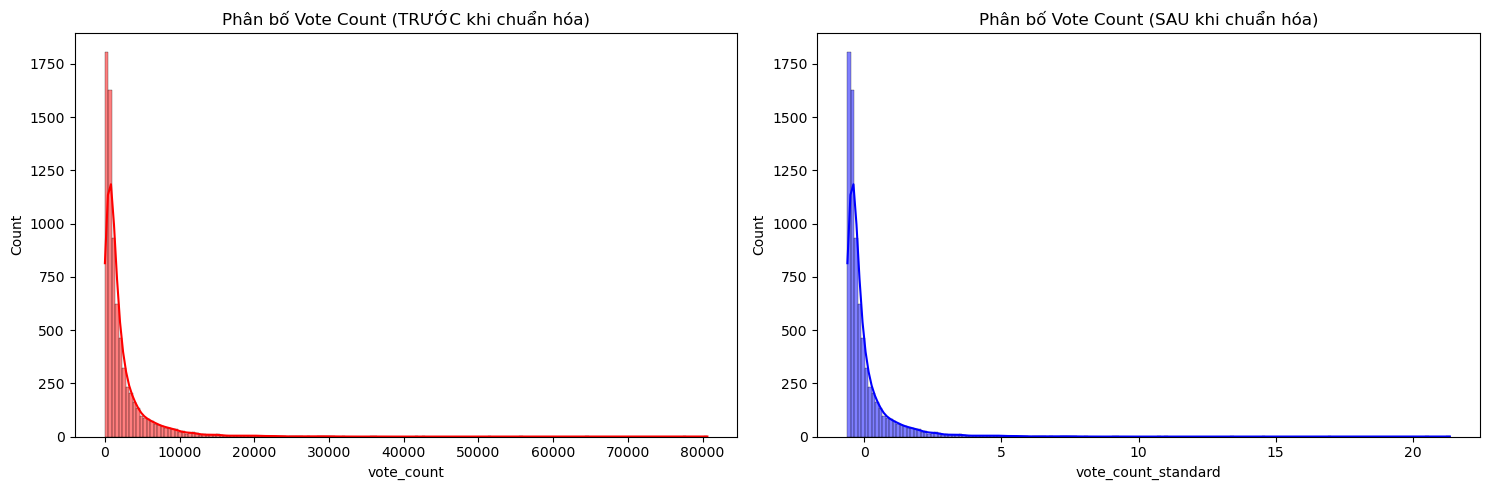

Mean sau chuẩn hóa: ~0.0
Std sau chuẩn hóa: ~1.0


In [18]:
# YOUR CODE GOES HERE
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['vote_count'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Phân bố Vote Count (TRƯỚC khi chuẩn hóa)')

sns.histplot(df['vote_count_standard'], kde=True, ax=axes[1], color='blue')
axes[1].set_title('Phân bố Vote Count (SAU khi chuẩn hóa)')

plt.tight_layout()
plt.show()

print(f"Mean sau chuẩn hóa: ~{round(df['vote_count_standard'].mean(), 3)}")
print(f"Std sau chuẩn hóa: ~{round(df['vote_count_standard'].std(), 3)}")

In [19]:
import plotly.express as px

fig = px.histogram(df, x='vote_count_standard', nbins=50, marginal='box',
                   title='Phân phối chuẩn (Z-score) của Vote Count',
                   color_discrete_sequence=['indianred'])

fig.update_layout(width=900, height=500)
fig.show()

## **2.4. One hot encoding**
- Chúng ta sẽ đến với bài toán lớn về xử lý dữ liệu đầu tiên, đó là `tags classification`.

### **TODO 8: Code comprehension (Hard)**
- Tier 1 là phương pháp `rule-based` truyền thống trong Machine Learning.
- Ở đây chúng ta dựa vào những `vocabs` sẵn có tại các cột `category`, `ingredients`, `cuisine`, `course` và `diet` để classify cột `tags` sang các cột này.
- Code này khá khó hiểu nhưng đều là thuần code chay với các khái niệm cơ bản về `if-else`. Đây vốn là bản chất của `rule-based` Machine Learning. Hãy xem đây là bài tập Code comprehension và fill vào `YOUR EXPLANATION GOES HERE` nhé.

In [20]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm

class RuleBasedClassifier:
    def __init__(self, target_cols):
        self.target_cols = target_cols
        self.vocab = {col: set() for col in target_cols}
        self.lemmatizer = WordNetLemmatizer() # Khởi tạo lemmatizer ở đây
        # Danh sách các từ vô nghĩa sẽ bỏ qua khi chuẩn hóa văn bản
        self.useless_tags = {
            'recipe', 'recipes', 'food', 'dish', 'idea', 'ideas', 'style', 'indian',
            'easy', 'quick', 'homemade', 'simple', 'best', 'healthy', 'traditional'
        }
        self.base_cols = ['category', 'ingredients', 'cuisine', 'course', 'diet', 'tags']

    # PUBLIC FUNCTIONS

    def fit(self, df):
        """Hàm học dữ liệu: Xây dựng bộ từ vựng (vocab) từ dữ liệu truyền vào."""
        print("Đang xây dựng bộ từ vựng (Vocabulary)...")
        self._build_vocab(df)
        return self

    def transform(self, df):
        """Hàm biến đổi: Chạy pipeline làm sạch và phân loại lại dữ liệu."""
        df_out = df.copy()

        # 1. YOUR EXPLANATION GOES HERE
        # Khởi tạo và làm sạch dữ liệu. Vòng lặp này duyệt qua các cột cơ sở (base_cols)
        # Nếu cột chưa tồn tại thì tạo mới. Sau đó áp dụng hàm `split_columns`(todo 4) để chuyển đổi chuỗi (string) thành danh sách (list) và lưu vào các cột có hậu tố `_clean` để bảo toàn dữ liệu gốc (Data Preservation).
        for col in tqdm(self.base_cols, desc="Transforming data type"):
            if col not in df_out.columns:
                df_out[col] = ""
            # Chạy hàm split_columns (hàm ngoài) để tách chuỗi thành list
            df_out[f"{col}_clean"] = df_out[col].apply(split_columns)

        # 2. YOUR EXPLANATION GOES HERE
        # Gọi hàm `_process_tags` để bắt đầu phân loại các tag từ cột 'tags_clean' chạy về đúng các cột đích (như category_clean, diet_clean...).
        # `tqdm.pandas()` hiển thị thanh tiến trình để dễ quản lý tiến độ thực thi.
        tqdm.pandas(desc="Processing tags")
        df_out = self._process_tags(df_out)

        print("\n✅ Tier 1's pipeline is completed!")
        return df_out

    def log_workload(self, df, file_path="log_writing_t1.txt"):
        # YOUR EXPLANATION GOES HERE
        # Lọc ra các công thức mà cột 'tags_clean' vẫn còn sót lại tags chưa được phân loại sau Tier 1 (chiều dài list > 0). Dùng `explode()` để trải phẳng list thành các phần tử đơn lẻ và loại bỏ giá trị rỗng cho dễ đếm
        mask = df['tags_clean'].apply(lambda x: len(x) > 0)
        df_leftovers = df[mask]
        all_tags = df_leftovers['tags_clean'].explode().dropna()

        # YOUR EXPLANATION GOES HERE
        # Ghi log vào file text để theo dõi hiệu suất thuật toán, giúp biết được Tier 1 đã thất bại ở những từ khóa nào (Tier 1 đã làm việc hiệu quả bao nhiêu %, và nhường lại bao nhiêu "rác" cho Tier 2.)
        with open(file_path, "w", encoding="utf-8") as f:
            f.write(f"--- TIER 1 REPORT ---\n")
            f.write(f"Total records: {len(df)}\n")
            f.write(f"Records needing Tier 2: {len(df_leftovers)}\n")
            f.write(f"Unique tags for Tier 2: {len(all_tags.unique())}\n\n")
            f.write("Top 20 leftover tags:\n")
            f.write(all_tags.value_counts().head(20).to_string())
        print(f"✅ Đã ghi log Tier 1 vào {file_path}")

    # PRIVATE FUNCTIONS

    def _norm_text(self, text): # Lưu ý cách Hỷ đặt tên hàm
        """Chuẩn hóa văn bản: lower case, xóa dấu câu, lemmatize và bỏ từ vô nghĩa."""
        text = str(text).lower()
        # YOUR EXPLANATION GOES HERE
        # Dùng Regular Expression (Regex) để giảm nhiễu
        # Loại bỏ toàn bộ dấu câu, ký tự đặc biệt, chỉ giữ lại chữ cái (bao gồm cả Unicode tiếng Việt) và khoảng trắng.
        text = re.sub(r'[^À-ỹ -ÿĀ-ſƀ-ɏḀ-ỿ\w\s]', '', text)
        # YOUR EXPLANATION GOES HERE
        # Cắt chuỗi thành mảng các từ đơn. Áp dụng kỹ thuật Lemmatization để đưa các biến thể của từ về dạng nguyên bản. Ví dụ: "running" -> "run", "mushrooms" -> "mushroom"
        # Giúp thuật toán so khớp chính xác hơn và maybe giúp giảm kích thước từ điển
        words = [self.lemmatizer.lemmatize(w) for w in text.split()] # List comprehension
        # YOUR EXPLANATION GOES HERE
        # Loại bỏ các Stop words (những từ zô tri không có giá trị phân loại) để máy tính không bị nhiễu ngữ nghĩa. Bước này giúp giảm kích thước không gian tính toán
        words = [w for w in words if w not in self.useless_tags]
        return " ".join(words).strip()

    def _build_vocab(self, df):
        """Trích xuất các giá trị độc nhất từ các cột mục tiêu để làm từ điển."""
        for col in tqdm(self.target_cols, desc="Building Vocab"):
            if col in df.columns:
                items = df[col].apply(split_columns).explode().dropna()
                norm_items = items.apply(self._norm_text)
                # YOUR EXPLANATION GOES HERE
                # Ép kiểu dữ liệu các từ vựng đã chuẩn hóa thành dạng `Set`
                self.vocab[col] = set(norm_items.unique()) # dtype set
                # ĐỘ PHỨC TẠP CỦA THUẬT TOÁN TÌM KIẾM TRONG SET LÀ BAO NHIÊU?
                # YOUR ANSWER HERE: O(1)
                # Cấu trúc dữ liệu Set trong Python được xây dựng dựa trên Hash Table. 
                # Khi tìm kiếm, nó chỉ cần băm giá trị và truy xuất thẳng vào ô nhớ, không cần duyệt qua từng phần tử (O(N)) như List.

    def _classify_tag(self, tag):
        """Dựa vào bộ vocab đã học, phán đoán xem một tag nên thuộc về cột nào."""
        norm_tag = self._norm_text(tag)
        if not norm_tag: return "tags_clean"

        tag_words = set(norm_tag.split())

        # Rule 1: Khớp chính xác 100% với một giá trị trong vocab
        for col_name in self.target_cols:
            if norm_tag in self.vocab[col_name]:
                return col_name

        # Rule 2: Kiểm tra xem tag có phải là một phần (subset) của cụm từ nào trong từ điển không
        # (vd: vocab có "chocolate cake", tag là "cake" -> subset)
        for col_name in self.target_cols:
            for v in self.vocab[col_name]:
                v_words = set(v.split())
                if not v_words: continue

                # Nếu toàn bộ từ trong tag đều nằm trong một cụm từ của vocab (ví dụ: 'cake' trong 'chocolate cake')
                if tag_words.issubset(v_words):
                    return col_name

        # Không thỏa mãn rule nào thì giữ nguyên ở cột tags_clean
        return "tags_clean"

    def _process_tags(self, df):
        """Duyệt qua cột tags, đẩy các tag có ý nghĩa cụ thể vào các cột tương ứng."""
        def _logic(row):
            new_tags = []
            # Copy lại danh sách hiện tại của các cột đích
            updates = {c: list(row.get(c, [])) for c in self.target_cols}

            for tag in row.get('tags_clean', []):
                target = self._classify_tag(tag) # Tìm cột đích phù hợp cho tag
                if target != 'tags_clean':
                    updates[target].append(tag) # Chuyển tag vào cột mới
                else:
                    new_tags.append(tag) # Giữ lại ở cột tags nếu không phân loại được

            row['tags_clean'] = new_tags
            # Cập nhật lại các cột đã được thêm tag mới
            for c, vals in updates.items():
                row[c] = vals
            return row

        return df.progress_apply(_logic, axis=1)

- Kế tiếp sẽ là Tier 2 là một head classfier dùng Gemini để hỗ trợ classify những tags mà Tier 1 chưa giải quyết hết (đọc file log).
- Tải `wordnet` là 1 thư viện hỗ trợ cho kỹ thuật `lematize` rất rất rất phổ biến trong code `LLM` from scratch: chuẩn hóa từ trong xử lý ngôn ngữ tự nhiên, giúp chuyển các từ có biến thể về dạng gốc chính xác, giữ lại ý nghĩa ngữ pháp.

In [21]:
import nltk # có sẵn trong Colab rồi!
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /home/diluan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [22]:
import json
from google import genai
from google.genai import types

class GeminiClassifier:
    def __init__(self, api_key, model_name='gemini-2.5-flash'):
        # YOUR EXPLANATION GOES HERE
        # Khởi tạo Client của Google GenAI SDK với API Key để xác thực kết nối.
        self.client = genai.Client(api_key=api_key)
        self.model_name = model_name
        # KỂ TÊN 2 MODEL_NAME KHÁC: gemini-2x/3x-pro/flash/flash-lite
        # YOUR EXPLANATION GOES HERE
        # Cấu hình buộc LLM phải trả kết quả về dưới dạng cấu trúc JSON (thay vì viết văn bản chữ nghĩa lan man). để code Backend có thể parse được câu trả lời của AI.
        self.config = types.GenerateContentConfig(
            response_mime_type="application/json"
        )

        self.target_mapping = {
            'Category': 'category_clean',
            'Course': 'course_clean',
            'Cuisine': 'cuisine_clean',
            'Diet': 'diet_clean',
            'Ingredients': 'ingredients_clean'
        }

    def process_batch(self, df): # Đã bỏ mapping_logic vì không dùng đến
        print("Creating batch from tags...")

        # 1. YOUR EXPLANATION GOES HERE
        # Thu thập toàn bộ các tags "cứng đầu" từ Tier 1. Dùng hàm `set()` để loại bỏ trùng lặp và đóng gói thành 1 danh sách duy nhất. (Thay vì gọi API hàng ngàn lần cho từng dòng, gom lại gọi 1 lần cho tiết kiệm
        all_leftover_tags = list(set(df['tags_clean'].explode().dropna()))

        if not all_leftover_tags:
            print("Không có tag nào kẹt, bỏ qua LLM!")
            return df

        print(f"Gom được {len(all_leftover_tags)} unique tags cần phân loại. Đang gửi cho Gemini (1 Request duy nhất)...")

        # 2. YOUR EXPLANATION GOES HERE
        # Prompt: Yêu cầu AI làm đúng 1 nhiệm vụ: Ép các tags vào đúng 5 danh mục có sẵn và trả về dạng JSON {"tag": "category"}.
        prompt = f"""
        Classify the following list of food tags into exactly ONE of these categories: [Category, Course, Cuisine, Diet, Ingredients].
        If a tag doesn't fit any, map it to "Unknown".

        Tags to classify: {all_leftover_tags}

        Output strictly as a JSON object: {{"tag_name": "Category_Name"}}
        """

        try:
            # 3. YOUR EXPLANATION GOES HERE
            # Gửi Request lên máy chủ Google (Gọi API). Sau khi nhận được Response, dùng hàm `json.loads()` để giải mã chuỗi văn bản JSON thành cấu trúc dictionary của Python để dễ truy xuất.
            response = self.client.models.generate_content(
                model=self.model_name,
                contents=prompt,
                config=self.config
            )
            gemini_mapping = json.loads(response.text)

            # 4. YOUR EXPLANATION GOES HERE
            # Lật từng món ăn ra kiểm tra và sắp xếp lại các tag dựa vào tấm bản đồ mà Gemini trả lại

            print("Mapping data to other columns...")
            def apply_gemini_fix(row):
                new_leftovers = []
                current_tags = row.get('tags_clean', [])

                # YOUR EXPLANATION GOES HERE
                # Duyệt qua các tag chưa được phân loại. Lấy kết quả (target_col) mà AI đã phán đoán từ Dictionary.
                # Nếu kết quả này hợp lệ (nằm trong target_mapping), đưa tag đó vào đúng cột tương ứng (actual_col).
                # Nếu AI trả về "Unknown", tag này chính thức bó tay và bị nhét lại vào danh sách rác (new_leftovers).
                for tag in current_tags:
                    target_col = gemini_mapping.get(tag, "Unknown")
                    if target_col in self.target_mapping:
                        actual_col = self.target_mapping[target_col]
                        row[actual_col].append(tag)
                    else:
                        new_leftovers.append(tag)

                row['tags_clean'] = new_leftovers
                return row

            # Cập nhật lại toàn bộ DataFrame bằng hàm map vừa định nghĩa
            df = df.apply(apply_gemini_fix, axis=1)
            print("✅ Tier 2's pipeline is completed!")

            return df, gemini_mapping # Trả về kèm mapping để ghi log

        except Exception as e:
            print(f"Error: {e}")

    def log_results(self, mapping_dict, file_path="log_writing_t2.txt"):
        with open(file_path, "w", encoding="utf-8") as f:
            f.write("--- TIER 2 GEMINI MAPPING ---\n")
            f.write(json.dumps(mapping_dict, indent=4, ensure_ascii=False))
        print(f"✅ Đã ghi log Tier 2 vào {file_path}")

- Xong 2 class là 2 head classifier rồi. Giờ cần 1 class để kết hợp 2 class, sau đó clean lại lần cuối những element bị trùng lặp trong 1 cột và giữa các cột.

In [23]:
import re
from tqdm import tqdm

class TagClassifier:
    def __init__(self, api_key):
        # Danh sách các cột đích cần dọn dẹp
        self.target_cols = ['category_clean', 'course_clean', 'cuisine_clean', 'diet_clean', 'ingredients_clean']
        # Cột tags_clean cũng cần được dọn dẹp "rác" còn sót lại
        self.all_clean_cols = self.target_cols + ['tags_clean']

        # Danh sách các từ "vô tri" cần loại bỏ
        self.silly_words = {'recipe', 'recipes', 'food', 'dish', 'idea', 'ideas', 'style', 'indian'}

        self.tier1 = RuleBasedClassifier(self.target_cols)
        self.tier2 = GeminiClassifier(api_key)

    def _post_processing(self, df):
        print("🧹 Đang thực hiện Super Post-processing (Xóa trùng ngữ nghĩa & Làm đẹp)...")
        df_out = df.copy()
        lemmatizer = WordNetLemmatizer()

        # Từ điển rác cần xóa trực tiếp khỏi kết quả
        silly_words_pattern = r'(?i)\b(recipe|recipes|food|dish|idea|ideas|style)\b'

        def get_core_set(s):
            """Hàm trích xuất 'cốt lõi' của chuỗi thành 1 Set các từ nguyên thể"""
            s = str(s).lower()
            s = re.sub(r'\(.*\)', '', s) # Bỏ ngoặc đơn (Capsicum)
            s = re.sub(r'[^\w\s]', '', s) # Bỏ ký tự đặc biệt
            # Lemmatize (mushrooms -> mushroom) và bỏ silly words
            words = [lemmatizer.lemmatize(w) for w in s.split() if w not in self.silly_words]
            return set(words)

        def format_final_string(s):
            """Hàm gọt dũa chuỗi để hiển thị đẹp nhất"""
            # Xóa các từ silly ngay trong chuỗi gốc (bất kể hoa thường)
            s = re.sub(silly_words_pattern, '', str(s))
            # Chuẩn hóa khoảng trắng dư thừa
            return " ".join(s.split()).strip()

        def process_row(row):
            seen_core_globally = [] # Lưu trữ các "Set từ cốt lõi" đã xuất hiện

            # 1. XỬ LÝ CÁC CỘT CHÍNH TRƯỚC
            for col in self.target_cols:
                current_list = row.get(col, [])
                final_col_list = []
                col_core_sets = [] # Lưu các Set của riêng cột này

                for item in current_list:
                    core_set = get_core_set(item)
                    if not core_set: continue

                    is_duplicate = False
                    # Kiểm tra xem set hiện tại có bị trùng lặp ngữ nghĩa không
                    for existing_set in col_core_sets:
                        # Nếu 'mushroom' nằm trong 'button mushroom' (Subset)
                        # Hoặc ngược lại 'button mushroom' bao hàm 'mushroom' (Superset)
                        if core_set.issubset(existing_set) or existing_set.issubset(core_set):
                            is_duplicate = True
                            break

                    if not is_duplicate:
                        col_core_sets.append(core_set)
                        seen_core_globally.append(core_set)

                        # Format lại chuỗi (mất chữ Recipes) và đưa vào kết quả
                        clean_item = format_final_string(item)
                        if clean_item: # Tránh trường hợp xóa xong chuỗi trống trơn
                            # Có thể dùng .title() nếu bạn muốn in hoa chữ cái đầu cho đồng nhất
                            final_col_list.append(clean_item)

                row[col] = final_col_list

            # 2. XỬ LÝ CỘT TAGS_CLEAN CUỐI CÙNG
            final_tags = []
            tag_core_sets = []
            for tag in row.get('tags_clean', []):
                core_set = get_core_set(tag)
                if not core_set: continue

                is_duplicate = False
                # Check chéo với tất cả các cột chính
                for existing_set in seen_core_globally + tag_core_sets:
                    if core_set.issubset(existing_set) or existing_set.issubset(core_set):
                        is_duplicate = True
                        break

                if not is_duplicate:
                    tag_core_sets.append(core_set)
                    clean_tag = format_final_string(tag)
                    if clean_tag:
                        final_tags.append(clean_tag)

            row['tags_clean'] = final_tags
            return row

        tqdm.pandas(desc="Final Cleaning")
        df_out = df_out.progress_apply(process_row, axis=1)
        return df_out

    def forward(self, df):
        print("🚀 Bắt đầu Pipeline phân loại Tag...")

        # Tiền xử lý: Tạo các cột _clean từ cột gốc (Dùng hàm split_columns ngoài class)
        df_out = df.copy()
        for col in ['tags', 'category', 'course', 'cuisine', 'diet', 'ingredients']:
            df_out[f"{col}_clean"] = df_out[col].apply(split_columns)

        # Step 1: Tier 1 (Rule-based)
        # Lưu ý: Truyền đúng tên cột đã có hậu tố _clean
        df_out = self.tier1.fit(df_out).transform(df_out)
        self.tier1.log_workload(df_out)

        # Step 2: Tier 2 (Gemini)
        # Hàm process_batch giờ trả về (df, mapping)
        df_out, mapping = self.tier2.process_batch(df_out)
        self.tier2.log_results(mapping)

        # Step 3: Post-processing (Xử lý tên hàm cho khớp)
        df_out = self._post_processing(df_out)

        print("\n✨ Full pipeline is completed! Dữ liệu đã sẵn sàng cho RecSys.")
        return df_out

### **TODO 9: Inference classifier (Medium)**
- Vậy chỉ cần chạy class ở trên là xong.
- Lấy `API_KEY` của bạn tại [AI Studio Google](https://aistudio.google.com/app/api-keys). Có thể dùng account mail UTS nhưng không thể dùng acc mail HCMUT.

In [24]:
import pandas as pd
import getpass

def run_pipeline(df_input, api_key):
    """
    Hàm thực thi toàn bộ quy trình dọn dẹp và phân loại Tag.
    """
    # Khởi tạo classifier
    # YOUR CODE GOES HERE
    classifier = TagClassifier(api_key=api_key)
    
    df_result = classifier.forward(df_input)

    return df_result

if __name__ == "__main__":
    # Thay API Key của bạn vào đây
    MY_API_KEY = getpass.getpass("Nhập Google Gemini API Key vào đây hehehêhê: ")

    # Chạy thử nghiệm
    df_cleaned = run_pipeline(df, MY_API_KEY)

🚀 Bắt đầu Pipeline phân loại Tag...
Đang xây dựng bộ từ vựng (Vocabulary)...


Processing tags: 100%|██████████| 7416/7416 [00:17<00:00, 432.42it/s]



✅ Tier 1's pipeline is completed!
✅ Đã ghi log Tier 1 vào log_writing_t1.txt
Creating batch from tags...
Gom được 225 unique tags cần phân loại. Đang gửi cho Gemini (1 Request duy nhất)...
Mapping data to other columns...
✅ Tier 2's pipeline is completed!
✅ Đã ghi log Tier 2 vào log_writing_t2.txt
🧹 Đang thực hiện Super Post-processing (Xóa trùng ngữ nghĩa & Làm đẹp)...


Final Cleaning: 100%|██████████| 7416/7416 [00:03<00:00, 2198.93it/s]


✨ Full pipeline is completed! Dữ liệu đã sẵn sàng cho RecSys.


In [25]:
index = 1
for col in ['tags', 'category', 'ingredients', 'course', 'cuisine']:
    print(f"{col}_old: {df_cleaned[col].iloc[index]}")
    print(f"{col}_clean: {df_cleaned[col+'_clean'].iloc[index]}\n")

tags_old: ['Vegetarian Recipes', 'Tomato Recipes', 'South Indian Recipes', 'Breakfast Recipe Ideas']
tags_clean: []

category_old: ['Indian Curry Recipes']
category_clean: ['Indian Curry']

ingredients_old: ['Sesame (Gingelly) Oil', 'Mustard seeds (Rai/ Kadugu)', 'Curry leaves', 'Garlic', 'Pearl onions (Sambar Onions)', 'Tomatoes', 'Tamarind', 'Turmeric powder (Haldi)', 'Salt', 'Jaggery']
ingredients_clean: ['Sesame (Gingelly) Oil', 'Mustard seeds (Rai/ Kadugu)', 'Curry leaves', 'Garlic', 'Pearl onions (Sambar Onions)', 'Tomatoes', 'Tamarind', 'Turmeric powder (Haldi)', 'Salt', 'Jaggery']

course_old: ['Lunch']
course_clean: ['Lunch', 'Breakfast']

cuisine_old: ['South Indian Recipes']
cuisine_clean: ['South Indian']



- Nhớ Hỷ nói sẽ clean `diet` sau không. Là lúc này đó!!

In [26]:
# YOUR CODE GOES HERE
df_cleaned['diet_clean'] = df_cleaned['diet_clean'].apply(lambda x: ['Standard'] if len(x) == 0 else x)
df_cleaned['diet_clean'].head()

0                 [Vegetarian]
1                 [Vegetarian]
2                 [Vegetarian]
3    [High Protein Vegetarian]
4    [High Protein Vegetarian]
Name: diet_clean, dtype: object

- Rõ ràng, các cột khác ngoài `tags` đã giàu ý nghĩa hơn rất nhiều. Xem như thuật toán tham lam thành công và chúng ta sẽ drop những cột cũ nhé.
- Nếu có load dataset từ file `.csv` lưu ý có thể lỗi `dtype` nhé.

In [27]:
# Lưu kết quả ra file mới để tránh gọi API lại tốn token và thời gian
df_cleaned.drop(columns=['tags', 'tags_clean', 'category', 'ingredients', 'course', 'cuisine'], inplace=True)
df_cleaned.to_csv("data/recipes_cleaned.csv", index=False)
print("💾 Save file at: data/recipes_cleaned.csv")

💾 Save file at: data/recipes_cleaned.csv


- Để hiển thị trên UI thì có thể sử dụng file vừa được lưu để hiển thị trên `forum` bằng việc parse `csv`.

### **TODO 10: OHE (Medium)**
- Cuối cùng cũng đến phần chính của mục này là `OHE`.
- One-Hot Encoding (OHE) là một kỹ thuật tiền xử lý dữ liệu cực kỳ phổ biến trong Machine Learning, dùng để chuyển đổi các biến phân loại (categorical data - dạng chữ hoặc nhãn) thành dạng số (nhị phân) để các thuật toán có thể hiểu và tính toán được.
- Để luyện tập với kiểu dữ liệu `np.array`, hãy hoàn thành hàm dưới đây:

In [28]:
import numpy as np

def one_hot_encode(df, col):
    """
    Hàm One-Hot Encoding mảng dữ liệu đầu vào.
    Hỗ trợ cả mảng chuỗi (strings) và mảng số (numbers).
    """

    data = df[col]

    exploded_series = df[col].explode().dropna()
    
    data = exploded_series.values
    row_indices = exploded_series.index.values

    # 1. Tìm các giá trị độc nhất (classes) và vị trí (index) của chúng trong mảng gốc
    classes, inverse_indices = np.unique(data, return_inverse=True)

    # 2. Lấy số lượng mẫu (số hàng) và số lượng phân lớp (số cột)
    n_samples = len(df) 
    n_classes = len(classes)

    # 3. Khởi tạo ma trận toàn số 0 với kích thước (n_samples, n_classes)
    ohe_matrix = np.zeros((n_samples, n_classes), dtype=int)

    # 4. Gán giá trị 1 vào đúng vị trí tương ứng bằng Advanced Indexing
    ohe_matrix[row_indices, inverse_indices] = 1

    return ohe_matrix, classes

In [29]:
ohe_matrix, classes = one_hot_encode(df_cleaned, 'course_clean')
print(ohe_matrix.shape)
# GIẢI THÍCH SHAPE NÀY XEM: YOUR ANSWER GOES HERE
# Ma trận trả về có kích thước N x M. Trong đó, N là tổng số công thức nấu ăn (tương ứng với số hàng của df_cleaned), và M là tổng số lượng các phân loại course độc nhất (ví dụ: Breakfast, Lunch, Dinner...). Nếu món ăn i thuộc khóa ăn j, thì phần tử ở tọa độ (i, j) của ma trận sẽ bằng 1, ngược lại bằng 0.

(7416, 25)


- In thử 1 dòng gốc và dòng ohe_matrix tương ứng để check.


In [30]:
# YOUR CODE GOES HERE
idx = 0
print(f"Dữ liệu gốc tại dòng {idx}:", df_cleaned['course_clean'].iloc[idx])

print("Ma trận OHE tương ứng")
print(ohe_matrix[idx])

print(f"Ma trận OHE tại dòng {idx}:")
for class_name, value in zip(classes, ohe_matrix[idx]):
    if value == 1:
        print(f" - {class_name}: {value} (HOT 🔥)")
    else:
        print(f" - {class_name}: {value}")

Dữ liệu gốc tại dòng 0: ['Dinner']
Ma trận OHE tương ứng
[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Ma trận OHE tại dòng 0:
 - After School Snack: 0
 - Appetizer: 0
 - Breakfast: 0
 - Brunch: 0
 - Dessert: 0
 - Dinner: 1 (HOT 🔥)
 - Indian Breakfast: 0
 - Indian Dessert For Parties: 0
 - Indian Dinner: 0
 - Indian Lunch: 0
 - Kids Lunch Box: 0
 - Lunch: 0
 - Main Course: 0
 - North Indian Breakfast: 0
 - North Indian Dinner: 0
 - North Indian Lunch: 0
 - Office Lunch Box: 0
 - One: 0
 - One Pot: 0
 - Side: 0
 - Snack: 0
 - South Indian Breakfast: 0
 - Weekend Dinner: 0
 - Weekend Lunch: 0
 - World Breakfast: 0


- Viết code cũng vất vả rồi, đáp án cho TODO trên có thể viết gọn theo hàm của `pandas` như sau nhá.
- Về mặt bản chất thì mọi thứ cũng như trên thôi nha nha nha.

In [31]:
df_exploded = df_cleaned.explode('course_clean')
df_ohe = pd.get_dummies(df_exploded, columns=['course_clean'])
df_ohe = df_ohe.groupby(level=0).sum()
df_ohe.head()

,recipe_title,url,vote_count,rating,description,diet,prep_time,cook_time,instructions,author,...,course_clean_North Indian Lunch,course_clean_Office Lunch Box,course_clean_One,course_clean_One Pot,course_clean_Side,course_clean_Snack,course_clean_South Indian Breakfast,course_clean_Weekend Dinner,course_clean_Weekend Lunch,course_clean_World Breakfast
0,Roasted Peppers And Mushroom Tortilla Pizza Re...,https://www.archanaskitchen.com/roasted-pepper...,434,4.958525,is a quicker version pizza to satisfy your cr...,Vegetarian,15.0,15.0,To begin making the Roasted Peppers And Mushro...,Divya Shivaraman,...,0,0,0,0,0,0,0,0,0,0
1,Thakkali Gotsu Recipe | Thakkali Curry | Spicy...,https://www.archanaskitchen.com/tomato-gotsu-r...,6846,9.864446,also known as the is a quick and easy to ma...,VegetarianVegetarian,20.0,40.0,To begin making Tomato Gotsu Recipe/ Thakkali ...,Archana DoshiArchana Doshi,...,0,0,0,0,0,0,0,0,0,0
2,Spicy Grilled Pineapple Salsa Recipe,https://www.archanaskitchen.com/spicy-grilled-...,2091,4.945959,Spicy Grilled Pineapple Salsa is a simple reci...,Vegetarian,10.0,0.0,To begin making the Spicy Grilled Pineapple Sa...,Archana's Kitchen,...,0,0,0,0,1,0,0,0,0,0
3,Karwar Style Dali Thoy Recipe - Toor dal Curry...,https://www.archanaskitchen.com/dali-thoy-reci...,1980,9.777778,The is a quintessential of Konkani dish whic...,High Protein VegetarianHigh Protein Vegetarian,10.0,40.0,To prepare Karwar Style Dali Thoy Recipe (Toor...,Jyothi RajeshJyothi Rajesh,...,0,0,0,0,1,0,0,0,0,0
4,Rajma Kofta In Milk And Poppy Seed Gravy Recip...,https://www.archanaskitchen.com/rajma-kofta-in...,690,9.657971,Koftas are traditional Indian recipes mostly w...,High Protein VegetarianHigh Protein Vegetarian,40.0,60.0,To begin making Rajma Kofta In Milk And Poppy ...,RUBY PATHAKRUBY PATHAK,...,0,0,0,0,1,0,0,0,0,0


- Trên thực tế, chúng ta sẽ không implement dài dòng như thế (dù chỉ có 3 dòng). Vậy hãy dùng `sklearn`  apply `ohe` cho tất cả các cột `categorical`

In [32]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

mlb = MultiLabelBinarizer()

categorical_cols = ['category_clean', 'course_clean', 'cuisine_clean', 'diet_clean', 'ingredients_clean']

df_final = df_cleaned.copy()

for col in categorical_cols:
    matrix = mlb.fit_transform(df_final[col])
    
    col_names = [f"{col}_{class_name}" for class_name in mlb.classes_]
    
    df_ohe_part = pd.DataFrame(matrix, columns=col_names, index=df_final.index)
    df_final = pd.concat([df_final, df_ohe_part], axis=1)

print("Đã thực hiện One-Hot Encoding bằng Sklearn thành công!")
print(f"Kích thước bảng dữ liệu hiện tại phình to ra: {df_final.shape}")

Đã thực hiện One-Hot Encoding bằng Sklearn thành công!
Kích thước bảng dữ liệu hiện tại phình to ra: (7416, 2275)


# **3. SPLIT DATASET**
- Thông thường `split dataset` là để chia `train set` và `test set`. Song, chúng ta sẽ khảo sát thao tác chuẩn bị dữ liệu này khi train hệ khuyến nghị.

### **TODO 11: Split dataset (Easy)**
- Giờ Hỷ cần 1 file `.csv` chứa các cột dùng để hiển thị trên 1 `card` của `forum` (lấy `vote_count` gốc hay `vote_count_standard`? *GỐC*) và 1 file `.csv` gồm những cột dùng để train hệ khuyến nghị (chỉ để lại text và số).

In [ ]:
# YOUR CODE GOES HERE
ui_columns = [
    'url', 'description', 'vote_count', 'rating', 
    'prep_time', 'cook_time', 'category_clean', 
    'course_clean', 'cuisine_clean', 'diet_clean', 'ingredients_clean'
]
ui_cols_exist = [col for col in ui_columns if col in df_final.columns]
df_ui = df_final[ui_cols_exist]

df_ui.to_csv("data/recipes_ui.csv", index=False)
print("✅ Đã lưu file giao diện: recipes_ui.csv")

ml_columns = [col for col in df_final.columns if col not in ui_cols_exist]
df_ml = df_final[ml_columns]

df_ml.to_csv("data/recipes_ml.csv", index=False)
print("✅ Đã lưu file Machine Learning: recipes_ml.csv")

✅ Đã lưu file giao diện: recipes_ui.csv
✅ Đã lưu file Machine Learning: recipes_ml.csv


### **TODO 12: Pull request (Medium)**
- Hãy `fork` repository lại và `clone` về máy `branch` của riêng mình.
- Hãy tạo 1 `pull request`, gọi tắt là `PR`, vào Github để upload `jupyter notebook` và 2 file `.csv` để nộp bài nha nha.
- Hãy mô tả `pull request` bằng markdown cho chuyên nghiệp nhé.